In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Date features such as year, month, and day_of_week capture temporal patterns in sales.

The feature is_month_end identifies whether the transaction occurred near the end of the month, which is often associated with higher sales due to salary cycles and promotional timing.

In [2]:
# Sort by date
df = df.sort_values('transaction_date')

# Split index
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (960, 13)
Test shape: (240, 13)


A temporal split is used instead of a random split because the data is time-ordered.

A random split would mix past and future data, causing data leakage and overly optimistic model performance.

Using the most recent 20% as the test set ensures that the model is evaluated on unseen future data, reflecting real-world deployment conditions.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define features and target
X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

# Categorical and numerical columns
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [col for col in X_train.columns if col not in cat_cols]

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

A ColumnTransformer is used to apply appropriate preprocessing to different feature types.

Categorical variables (`promotion_type`, `location_type`, `store_size`) are encoded using One-Hot Encoding to convert them into numerical format.

Numerical features are scaled using StandardScaler to ensure all features contribute equally to the model.

The preprocessing pipeline is fit only on the training data and then applied to the test data, preventing data leakage and ensuring a fair evaluation.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    
    results[name] = (rmse, mae, preds)
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)


Linear Regression
RMSE: 27.12145116489063
MAE: 21.052926674588395

Random Forest
RMSE: 30.841610008504205
MAE: 24.240625


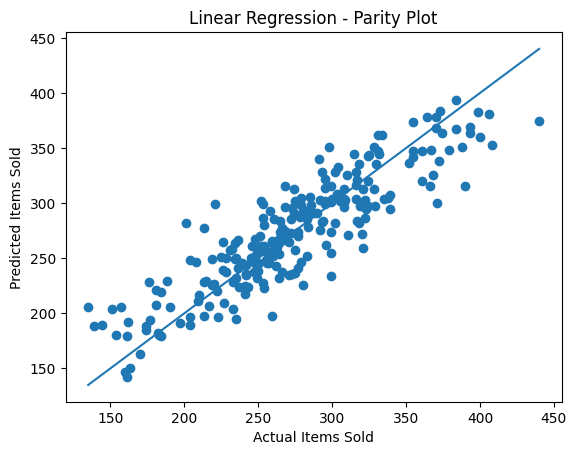

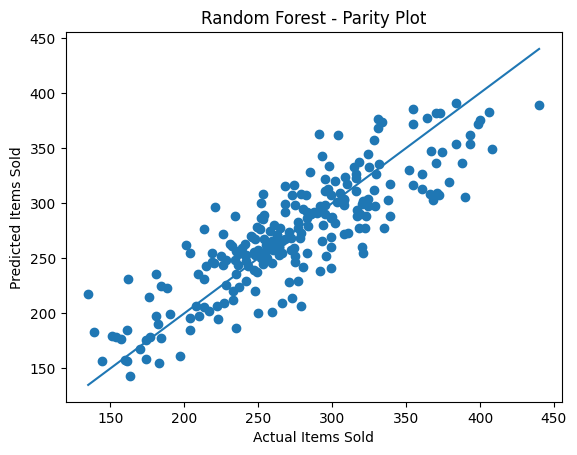

In [5]:
import matplotlib.pyplot as plt

for name in models.keys():
    preds = results[name][2]
    
    plt.figure()
    plt.scatter(y_test, preds)
    
    # Diagonal line
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()])
    
    plt.title(f"{name} - Parity Plot")
    plt.xlabel("Actual Items Sold")
    plt.ylabel("Predicted Items Sold")
    
    plt.show()

The parity plot compares predicted values with actual values.

Points closer to the diagonal line indicate better predictions.

Deviations from the line represent prediction errors.

In [6]:
# Train Random Forest pipeline again (to extract importance cleanly)
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipe.fit(X_train, y_train)

# Extract feature names
ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(cat_cols)

all_features = list(cat_features) + num_cols

# Get importances
importances = rf_pipe.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 5 features
feat_imp.head(5)

,feature,importance
13,is_festival,0.173473
10,store_size_small,0.167683
7,location_type_urban,0.108378
17,day_of_week,0.086316
12,is_weekend,0.061208


Feature importance from the Random Forest model indicates which variables most influence predictions.

The top features (e.g., promotion type, competition density, or store size) have the strongest impact on items sold.

These insights can help the business focus on the most important drivers of sales when designing promotions.